# Marketplace Intelligence | Inteligência de Marketplace

## 🇧🇷 Português

Após analisar a evolução da receita ao longo do tempo, o próximo passo é entender **quem está gerando essa receita**.

Em marketplaces, a concentração de receita entre poucos sellers pode representar:

- Dependência comercial;
- Risco operacional;
- Baixa diversificação do ecossistema.

Nesta análise, vamos investigar:

1. Quais sellers geram mais receita;
2. Qual percentual da receita está concentrado entre os principais sellers;
3. Se existe risco de concentração comercial.

---

## 🇺🇸 English

After analyzing revenue evolution over time, the next step is to understand **who is generating that revenue**.

In marketplaces, revenue concentration among a small number of sellers may indicate:

- Commercial dependency;
- Operational risk;
- Low ecosystem diversification.

In this analysis, we will investigate:

1. Which sellers generate the most revenue;
2. What percentage of revenue is concentrated among top sellers;
3. Whether there is commercial concentration risk.

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_ingestion import build_marketplace_base

## Data Loading | Carregamento dos Dados

### 🇧🇷 Português

Nesta etapa, carregamos a base analítica de marketplace, preservando granularidade por item.

Isso permite analisar:

- sellers;
- produtos;
- categorias;
- comportamento de receita.

---

### 🇺🇸 English

In this step, we load the marketplace analytical dataset while preserving item-level granularity.

This allows us to analyze:

- sellers;
- products;
- categories;
- revenue behavior.

In [2]:
df = build_marketplace_base()

df.head()

Marketplace base created successfully.
Rows: 112650
Columns: 16


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,72.19,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,259.83,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,216.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,25.78,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,218.04,ferramentas_jardim


## Seller Revenue Ranking | Ranking de Receita por Seller

### 🇧🇷 Português

Agora vamos identificar quais sellers geram mais receita dentro do ecossistema.

Essa análise ajuda a responder:

> A empresa depende de poucos sellers para sustentar sua receita?

---

### 🇺🇸 English

Now we will identify which sellers generate the most revenue within the ecosystem.

This analysis helps answer:

> Is the company dependent on a small number of sellers to sustain revenue?

In [3]:
seller_revenue = (
    df.groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

top_10_sellers = seller_revenue.head(10)

top_10_sellers

seller_id
7c67e1448b00f6e969d365cea6b010ab    507166.91
1025f0e2d44d7041d6cf58b6550e0bfa    308222.04
4a3ca9315b744ce9f8e9374361493884    301245.27
1f50f920176fa81dab994f9023523100    290253.42
53243585a1d6dc2643021fd1853d8905    284903.08
da8622b14eb17ae2831f4ac5b9dab84a    272219.32
4869f7a5dfa277a7dca6462dcf3b52b2    264166.12
955fee9216a65b617aa5c0531780ce60    236322.30
fa1c13f2614d7b5c4749cbc52fecda94    206513.23
7e93a43ef30c4f03f38b393420bc753a    185134.21
Name: payment_value, dtype: float64

## Revenue Visualization | Visualização da Receita

### 🇧🇷 Português

A visualização abaixo mostra os sellers com maior participação em receita.

---

### 🇺🇸 English

The chart below shows the sellers with the highest revenue contribution.

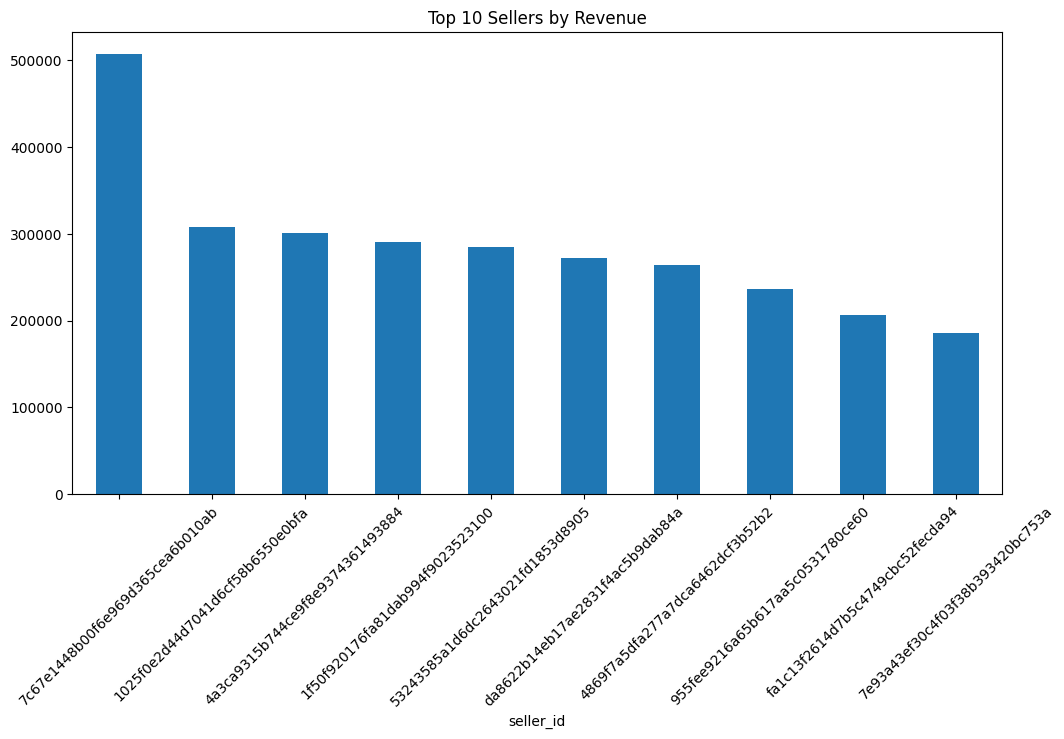

In [4]:
top_10_sellers.plot(
    kind="bar",
    figsize=(12, 6),
    title="Top 10 Sellers by Revenue"
)

plt.xticks(rotation=45)
plt.show()

## Revenue Concentration | Concentração de Receita

### 🇧🇷 Português

Agora vamos medir quanto da receita total está concentrada entre os 10 principais sellers.

A fórmula utilizada foi:

```

Top Seller Share = (Top Sellers Revenue / Total Revenue) × 100

```

---

### 🇺🇸 English

Now we will measure how much of total revenue is concentrated among the top 10 sellers.

The formula used was:

```

Top Seller Share = (Top Sellers Revenue / Total Revenue) × 100

```

In [5]:
top_10_share = (
    top_10_sellers.sum()
    / seller_revenue.sum()
) * 100

top_10_share

np.float64(14.064048425843833)

## Key Insights | Principais Insights

### 🇧🇷 Português

A análise revelou que os 10 maiores sellers representam apenas **14.06% da receita total** da :contentReference[oaicite:3]{index=3}.

Esse resultado sugere um marketplace com **baixa concentração comercial**, reduzindo riscos relacionados à dependência de poucos parceiros estratégicos.

Além disso:

- O seller líder gerou aproximadamente **R$ 507 mil**;
- O décimo seller gerou aproximadamente **R$ 185 mil**;
- A diferença entre ambos foi de aproximadamente **2.74x**, indicando liderança, mas sem dominância extrema.

### Implicações de negócio:

- Menor risco operacional;
- Maior resiliência comercial;
- Ecossistema potencialmente mais saudável e escalável.

---

### 🇺🇸 English

The analysis revealed that the top 10 sellers represent only **14.06% of total revenue** for :contentReference[oaicite:4]{index=4}.

This suggests a marketplace with **low commercial concentration**, reducing dependency risks on a small number of strategic partners.

Additionally:

- The leading seller generated approximately **BRL 507k**;
- The tenth seller generated approximately **BRL 185k**;
- The gap between them was approximately **2.74x**, indicating leadership without extreme dominance.

### Business implications:

- Lower operational risk;
- Higher commercial resilience;
- Potentially healthier and more scalable ecosystem.

## Pareto Analysis | Análise de Pareto

### 🇧🇷 Português

Agora vamos testar se a distribuição segue o princípio de Pareto (80/20), onde uma pequena parcela dos sellers pode gerar a maior parte da receita.

---

### 🇺🇸 English

Now we will test whether the distribution follows the Pareto principle (80/20), where a small portion of sellers may generate most of the revenue.

In [6]:
seller_revenue_df = (
    seller_revenue
    .reset_index()
)

seller_revenue_df.columns = [
    "seller_id",
    "revenue"
]

seller_revenue_df["cumulative_revenue_pct"] = (
    seller_revenue_df["revenue"]
    .cumsum()
    / seller_revenue_df["revenue"].sum()
) * 100

seller_revenue_df["seller_pct"] = (
    range(1, len(seller_revenue_df) + 1)
)

seller_revenue_df["seller_pct"] = (
    seller_revenue_df["seller_pct"]
    / len(seller_revenue_df)
) * 100

pareto_cutoff = seller_revenue_df[
    seller_revenue_df["cumulative_revenue_pct"] >= 80
].iloc[0]

pareto_cutoff

seller_id                 02ecc2a19303f05e59ce133fd923fff7
revenue                                            7844.22
cumulative_revenue_pct                           80.035194
seller_pct                                       17.899838
Name: 553, dtype: object

## Pareto Insights | Insights de Pareto

### 🇧🇷 Português

A análise de Pareto revelou que aproximadamente **17.9% dos sellers geram 80.03% da receita total**.

Esse resultado indica que a distribuição de receita da :contentReference[oaicite:4]{index=4} segue fortemente o princípio de Pareto, apresentando concentração comercial significativa.

### O que isso significa?

Apesar dos 10 maiores sellers representarem apenas **14.06% da receita**, a análise completa mostrou que uma parcela relativamente pequena dos sellers sustenta a maior parte do faturamento.

### Implicações estratégicas:

- Existe dependência estrutural de sellers de alta performance;
- A perda de sellers estratégicos pode impactar significativamente a receita;
- Programas de retenção e relacionamento com top sellers podem ser críticos.

---

### 🇺🇸 English

Pareto analysis revealed that approximately **17.9% of sellers generate 80.03% of total revenue**.

This indicates that :contentReference[oaicite:5]{index=5} revenue distribution strongly follows the Pareto principle, showing significant commercial concentration.

### What does this mean?

Although the top 10 sellers represent only **14.06% of total revenue**, the full distribution analysis showed that a relatively small portion of sellers supports most of the business revenue.

### Strategic implications:

- There is structural dependency on high-performing sellers;
- Losing strategic sellers may significantly impact revenue;
- Retention and relationship programs for top sellers may be critical.

## Seller Segmentation | Segmentação de Sellers

### 🇧🇷 Português

Nem todos os sellers contribuem da mesma forma para a receita.

Nesta etapa, vamos segmentar os sellers em grupos de performance utilizando quartis estatísticos.

Objetivo:

Identificar sellers de alta performance, sellers intermediários e sellers de cauda longa.

---

### 🇺🇸 English

Not all sellers contribute equally to revenue.

In this step, we will segment sellers into performance groups using statistical quartiles.

Objective:

Identify high-performing sellers, mid-performing sellers, and long-tail sellers.

In [7]:
seller_revenue_df = (
    seller_revenue
    .reset_index()
)

seller_revenue_df.columns = [
    "seller_id",
    "revenue"
]

In [8]:
seller_revenue_df["segment"] = pd.qcut(
    seller_revenue_df["revenue"],
    q=4,
    labels=["Long Tail", "Emerging", "Strong", "Top Performers"]
)

seller_revenue_df.head()

,seller_id,revenue,segment
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,Top Performers
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,Top Performers
2,4a3ca9315b744ce9f8e9374361493884,301245.27,Top Performers
3,1f50f920176fa81dab994f9023523100,290253.42,Top Performers
4,53243585a1d6dc2643021fd1853d8905,284903.08,Top Performers


In [9]:
segment_summary = (
    seller_revenue_df["segment"]
    .value_counts()
    .sort_index()
)

segment_summary

segment
Long Tail         774
Emerging          774
Strong            773
Top Performers    774
Name: count, dtype: int64

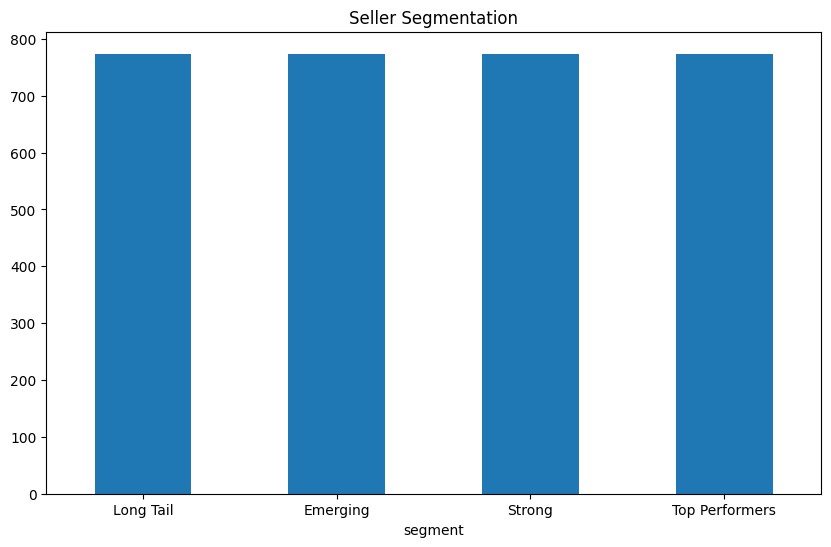

In [10]:
segment_summary.plot(
    kind="bar",
    figsize=(10, 6),
    title="Seller Segmentation"
)

plt.xticks(rotation=0)
plt.show()

## Segment Distribution | Distribuição dos Segmentos

### 🇧🇷 Português

A segmentação por quartis distribuiu os sellers de forma equilibrada:

- Long Tail: 774 sellers
- Emerging: 774 sellers
- Strong: 773 sellers
- Top Performers: 774 sellers

Como a metodologia utilizada foi quartil estatístico (`qcut`), cada grupo possui aproximadamente a mesma quantidade de sellers.

Importante:

Essa análise representa distribuição populacional, não impacto financeiro.

O próximo passo é medir quanto de receita cada segmento realmente gera.

---

### 🇺🇸 English

Quartile segmentation distributed sellers evenly:

- Long Tail: 774 sellers
- Emerging: 774 sellers
- Strong: 773 sellers
- Top Performers: 774 sellers

Since the method used was statistical quartiles (`qcut`), each group contains approximately the same number of sellers.

Important:

This analysis represents population distribution, not financial impact.

The next step is to measure how much revenue each segment actually generates.    

In [11]:
segment_revenue = (
    seller_revenue_df
    .groupby("segment")["revenue"]
    .sum()
    .sort_values()
)

segment_revenue

segment
Long Tail           116586.10
Emerging            548876.23
Strong             2017517.21
Top Performers    17625155.17
Name: revenue, dtype: float64

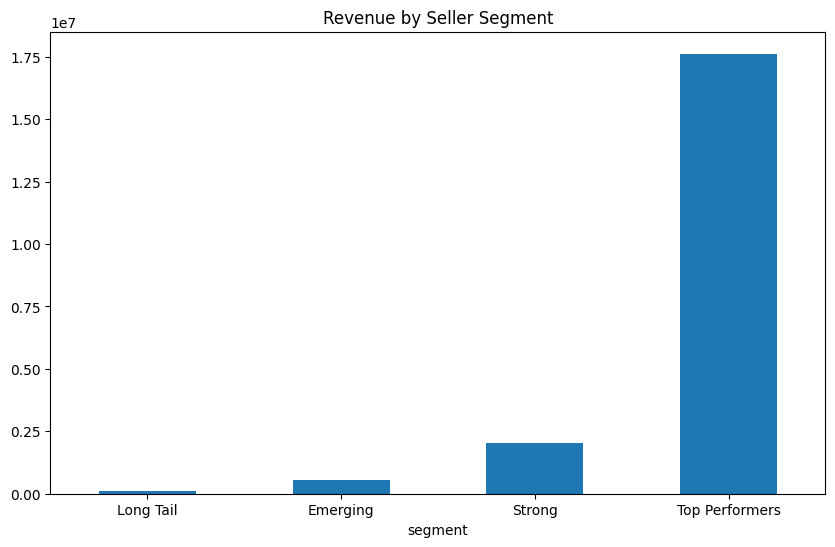

In [12]:
segment_revenue.plot(
    kind="bar",
    figsize=(10, 6),
    title="Revenue by Seller Segment"
)

plt.xticks(rotation=0)
plt.show()

## Segment Revenue Insights | Insights de Receita por Segmento

### 🇧🇷 Português

Apesar da distribuição equilibrada de sellers entre os quartis, a receita mostrou forte concentração.

Principais descobertas:

- **Top Performers:** R$ 17.6M
- **Strong:** R$ 2.0M
- **Emerging:** R$ 548K
- **Long Tail:** R$ 116K

### Insight estatístico:

O segmento **Top Performers** gera aproximadamente **151x mais receita** do que o segmento **Long Tail**.

### Interpretação de negócio:

Isso sugere:

- Forte concentração de performance;
- Dependência operacional dos melhores sellers;
- Potencial necessidade de programas de retenção e desenvolvimento comercial.

---

### 🇺🇸 English

Although seller distribution across quartiles is balanced, revenue shows strong concentration.

Key findings:

- **Top Performers:** BRL 17.6M
- **Strong:** BRL 2.0M
- **Emerging:** BRL 548K
- **Long Tail:** BRL 116K

### Statistical insight:

The **Top Performers** segment generates approximately **151x more revenue** than the **Long Tail** segment.

### Business interpretation:

This suggests:

- Strong performance concentration;
- Operational dependency on top sellers;
- Potential need for retention and seller development programs.

## Category Intelligence | Inteligência por Categoria

### 🇧🇷 Português

Após identificar concentração entre sellers, o próximo passo é investigar se essa performance está associada às categorias em que eles atuam.

Objetivos desta análise:

1. Identificar categorias líderes em receita;
2. Medir concentração de receita por categoria;
3. Avaliar dependência comercial por vertical de produto.

---

### 🇺🇸 English

After identifying seller concentration, the next step is to investigate whether this performance is associated with product categories.

Objectives of this analysis:

1. Identify leading revenue categories;
2. Measure revenue concentration by category;
3. Evaluate commercial dependency across product verticals.

In [13]:
category_revenue = (
    df.groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

top_10_categories = category_revenue.head(10)

top_10_categories

product_category_name
cama_mesa_banho           1712553.67
beleza_saude              1657373.12
informatica_acessorios    1585330.45
moveis_decoracao          1430176.39
relogios_presentes        1429216.68
esporte_lazer             1392127.56
utilidades_domesticas     1094758.13
automotivo                 852294.33
ferramentas_jardim         838280.75
cool_stuff                 779698.00
Name: payment_value, dtype: float64

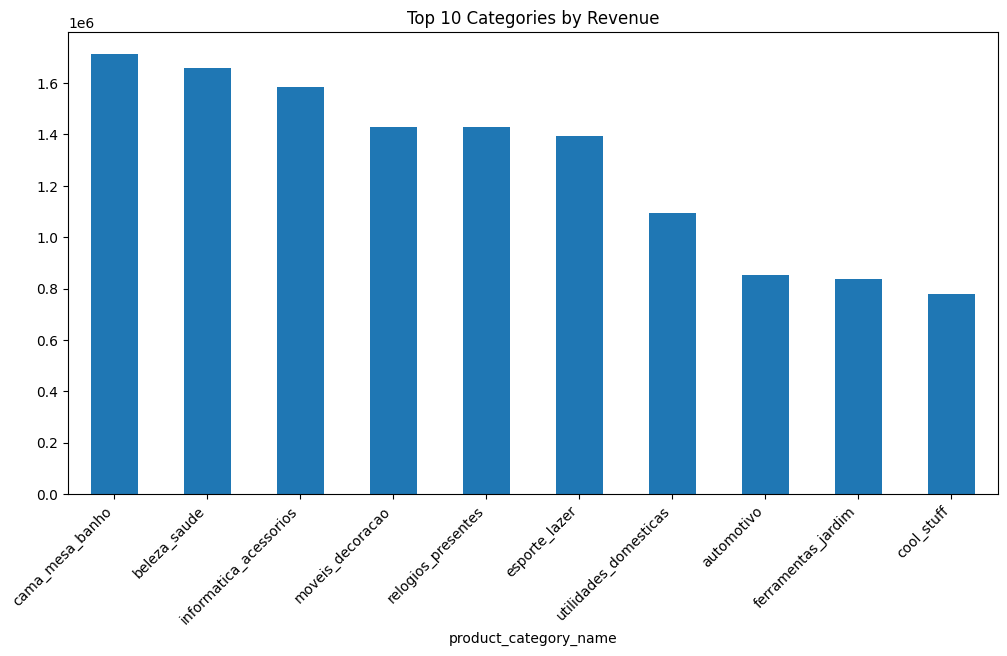

In [14]:
top_10_categories.plot(
    kind="bar",
    figsize=(12, 6),
    title="Top 10 Categories by Revenue"
)

plt.xticks(rotation=45, ha="right")
plt.show()

In [15]:
top_10_category_share = (
    top_10_categories.sum()
    / category_revenue.sum()
) * 100

top_10_category_share

np.float64(63.68285722306381)

In [16]:
df["product_category_name"].isna().sum()

np.int64(1603)

## Category Intelligence | Inteligência por Categoria

### 🇧🇷 Português

A análise mostrou forte concentração de receita entre categorias.

Principais descobertas:

- As 10 principais categorias representam **63.68% da receita total**;
- A categoria líder foi **cama_mesa_banho**, com aproximadamente **R$ 1.71M**;
- A décima categoria gerou aproximadamente **R$ 779K**;
- A diferença entre a primeira e a décima categoria foi de aproximadamente **2.2x**.

### Qualidade dos dados:

Foram identificados **1.603 valores nulos** em `product_category_name`, representando aproximadamente **1.42% da base**, impacto considerado baixo para a análise.

### Implicações de negócio:

- Existe dependência comercial de categorias líderes;
- Estratégias promocionais podem estar concentradas em poucas verticais;
- Diversificação de categorias pode aumentar resiliência do marketplace.

---

### 🇺🇸 English

The analysis showed strong revenue concentration across categories.

Key findings:

- The top 10 categories represent **63.68% of total revenue**;
- The leading category was **cama_mesa_banho**, generating approximately **BRL 1.71M**;
- The tenth category generated approximately **BRL 779K**;
- The difference between first and tenth place was approximately **2.2x**.

### Data quality:

A total of **1,603 missing values** were identified in `product_category_name`, representing approximately **1.42% of the dataset**, considered low impact.

### Business implications:

- There is commercial dependency on leading categories;
- Promotional strategies may be concentrated in a few verticals;
- Category diversification may improve marketplace resilience.

### Análise Estatística | Statistical Analysis

#### 🇧🇷 Português

As top categorias apresentaram:

- **Média:** R$ 1.28M
- **Mediana:** R$ 1.41M
- **Desvio padrão:** R$ 356K
- **Coeficiente de variação:** ~27.9%

### Interpretação:

A mediana acima da média sugere leve assimetria na distribuição.

O coeficiente de variação indica volatilidade moderada, mostrando que existem categorias líderes, porém sem monopolização extrema.

---

#### 🇺🇸 English

Top categories presented:

- **Mean:** BRL 1.28M
- **Median:** BRL 1.41M
- **Standard deviation:** BRL 356K
- **Coefficient of variation:** ~27.9%

### Interpretation:

Median being above the mean suggests slight skewness.

The coefficient of variation indicates moderate volatility, showing category leadership without extreme monopolization.

## Seller Segment × Category | Segmento de Seller por Categoria

### 🇧🇷 Português

Após analisar sellers e categorias separadamente, o próximo passo é conectar ambas as dimensões.

Objetivo:

Descobrir quais categorias são mais exploradas pelos sellers de alta performance.

Pergunta de negócio:

A performance superior dos sellers vem de execução comercial...

ou de posicionamento em categorias mais rentáveis?

---

### 🇺🇸 English

After analyzing sellers and categories separately, the next step is connecting both dimensions.

Objective:

Discover which categories are most explored by high-performing sellers.

Business question:

Does superior seller performance come from execution...

or from positioning in more profitable categories?

In [17]:
df_segmented = df.merge(
    seller_revenue_df[
        ["seller_id", "segment"]
    ],
    on="seller_id",
    how="left"
)

df_segmented.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,product_category_name,segment
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,72.19,cool_stuff,Top Performers
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,259.83,pet_shop,Top Performers
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,216.87,moveis_decoracao,Top Performers
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,25.78,perfumaria,Strong
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,218.04,ferramentas_jardim,Strong


In [18]:
top_sellers_df = df_segmented[
    df_segmented["segment"] == "Top Performers"
]

top_sellers_df.shape

(93928, 17)

In [19]:
top_seller_categories = (
    top_sellers_df
    .groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_seller_categories

product_category_name
cama_mesa_banho           1613559.20
informatica_acessorios    1452639.16
beleza_saude              1425258.16
relogios_presentes        1388145.98
moveis_decoracao          1259730.13
esporte_lazer             1125014.11
utilidades_domesticas      890144.07
ferramentas_jardim         738448.47
cool_stuff                 712661.75
automotivo                 636977.24
Name: payment_value, dtype: float64

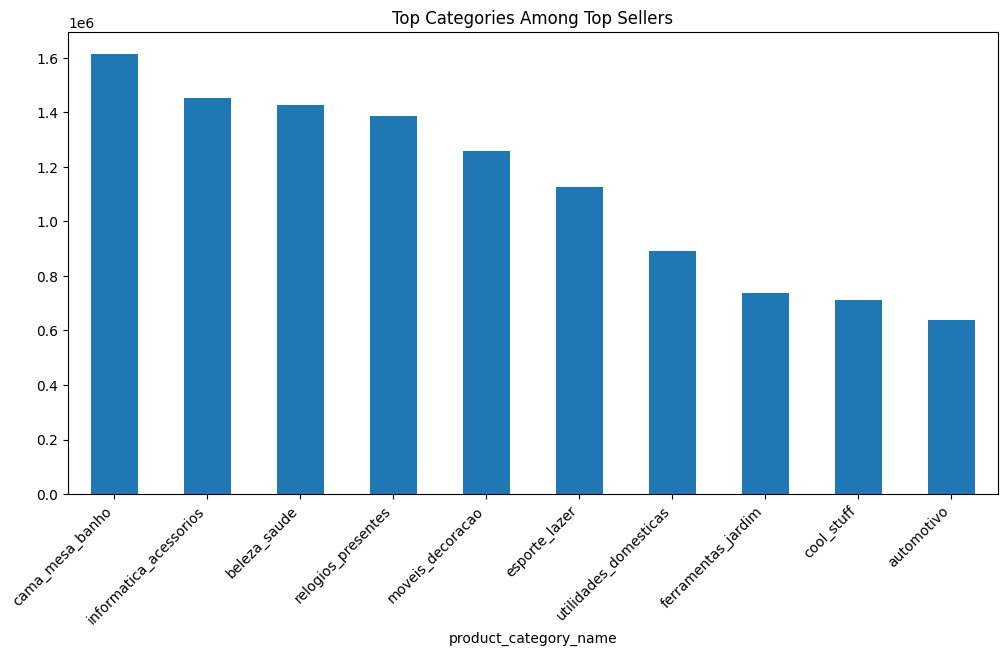

In [20]:
top_seller_categories.plot(
    kind="bar",
    figsize=(12, 6),
    title="Top Categories Among Top Sellers"
)

plt.xticks(rotation=45, ha="right")
plt.show()

## Seller Segment × Category Insights | Insights de Segmento por Categoria

### 🇧🇷 Português

A análise cruzada revelou que sellers classificados como **Top Performers** concentram suas operações principalmente nas mesmas categorias líderes do marketplace.

Principais descobertas:

- **cama_mesa_banho:** R$ 1.61M
- **informatica_acessorios:** R$ 1.45M
- **beleza_saude:** R$ 1.43M
- **relogios_presentes:** R$ 1.39M

### Insight estratégico:

Isso sugere que a alta performance dos sellers não depende apenas de execução operacional.

Existe forte influência de:

- Posicionamento estratégico em categorias rentáveis;
- Seleção de portfólio;
- Product-market fit.

### Análise estatística:

- **Média:** R$ 1.12M
- **Mediana:** R$ 1.19M
- **Desvio padrão:** R$ 355K
- **Coeficiente de variação:** ~31.6%

### Interpretação:

Mesmo entre os sellers top performers, não existe monopolização extrema entre categorias.

---

### 🇺🇸 English

Cross-analysis revealed that sellers classified as **Top Performers** concentrate their operations in the same leading marketplace categories.

Key findings:

- **cama_mesa_banho:** BRL 1.61M
- **informatica_acessorios:** BRL 1.45M
- **beleza_saude:** BRL 1.43M
- **relogios_presentes:** BRL 1.39M

### Strategic insight:

This suggests that seller performance is not driven only by operational execution.

There is strong influence from:

- Strategic positioning in profitable categories;
- Portfolio selection;
- Product-market fit.

### Statistical analysis:

- **Mean:** BRL 1.12M
- **Median:** BRL 1.19M
- **Standard deviation:** BRL 355K
- **Coefficient of variation:** ~31.6%

### Interpretation:

Even among top-performing sellers, there is no extreme category monopolization.

# Executive Summary | Resumo Executivo

## 🇧🇷 Português

Esta análise teve como objetivo entender os principais drivers de receita dentro do marketplace da :contentReference[oaicite:0]{index=0}, investigando sellers, categorias e concentração comercial.

### Principais descobertas

## 1. Forte concentração entre sellers

A análise de Pareto revelou que aproximadamente **17.9% dos sellers geram 80.03% da receita total**.

### Implicação:

Existe dependência estrutural de sellers de alta performance.

---

## 2. Alta desigualdade de performance

A segmentação por quartis mostrou que sellers classificados como **Top Performers** geram aproximadamente **151x mais receita** que sellers de **Long Tail**.

### Implicação:

A performance do ecossistema depende fortemente de um grupo reduzido de sellers.

---

## 3. Dependência de categorias líderes

As 10 principais categorias representam aproximadamente **63.68% da receita total**.

Categorias líderes:

- cama_mesa_banho
- beleza_saude
- informatica_acessorios
- moveis_decoracao

### Implicação:

Existe concentração comercial em poucas verticais estratégicas.

---

## 4. Performance associada ao category positioning

Os sellers Top Performers concentram atuação exatamente nas categorias líderes do marketplace.

### Implicação:

A alta performance parece estar associada não apenas à execução operacional, mas também à escolha estratégica de portfólio.

---

## Recomendações estratégicas

### Curto prazo

- Criar programas de retenção para sellers Top Performers;
- Monitorar churn de sellers estratégicos;
- Acompanhar concentração de receita mensalmente.

### Médio prazo

- Desenvolver sellers de segmentos Emerging e Strong;
- Criar incentivos comerciais para sellers Long Tail.

### Longo prazo

- Diversificar categorias com menor participação;
- Reduzir dependência estrutural de sellers e categorias dominantes.

---

## Conclusão Final

O marketplace apresenta sinais de saúde comercial e escala, porém possui concentração estrutural relevante entre sellers e categorias.

A sustentabilidade futura dependerá da capacidade de equilibrar crescimento, retenção e diversificação.

---

# 🇺🇸 English

This analysis aimed to understand the main revenue drivers inside the :contentReference[oaicite:1]{index=1} marketplace by investigating sellers, categories, and commercial concentration.

### Key findings

## 1. Strong seller concentration

Pareto analysis revealed that approximately **17.9% of sellers generate 80.03% of total revenue**.

### Implication:

There is structural dependency on high-performing sellers.

---

## 2. High performance inequality

Quartile segmentation showed that **Top Performers** generate approximately **151x more revenue** than **Long Tail** sellers.

### Implication:

Marketplace performance depends heavily on a relatively small seller group.

---

## 3. Category dependency

The top 10 categories represent approximately **63.68% of total revenue**.

Leading categories:

- cama_mesa_banho
- beleza_saude
- informatica_acessorios
- moveis_decoracao

### Implication:

There is commercial concentration across a few strategic product verticals.

---

## 4. Performance linked to category positioning

Top Performers are concentrated in the marketplace’s leading categories.

### Implication:

High performance seems driven not only by operational execution, but also by strategic portfolio positioning.

---

## Strategic recommendations

### Short term

- Build retention programs for Top Performers;
- Monitor strategic seller churn;
- Track revenue concentration monthly.

### Medium term

- Develop sellers in Emerging and Strong segments;
- Create commercial incentives for Long Tail sellers.

### Long term

- Diversify lower-performing categories;
- Reduce structural dependency on dominant sellers and categories.

---

## Final conclusion

The marketplace shows strong signs of commercial health and scalability, but also presents relevant structural concentration.

Long-term sustainability will depend on balancing growth, retention, and diversification.